# Classificação de piRNAs


In [ ]:
from google.colab import drive
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns


In [ ]:
!pip install scikeras

In [ ]:

from keras import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import Adam
from keras.models import load_model
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

### Leitura de Dados

In [ ]:
root = '/content/drive/MyDrive/Redes Neurais/piRNAs/data'

In [ ]:
drive.mount('/content/drive')

features = ['kmers', 'subsequence','mismatch' ]

path_train = root + '/train/'
path_test =  root + '/test/'
print(path_train)
train_data  = {}
test_data  = {}

#Leitura dos dados
for feature in features:
  train_data[feature] = {}
  test_data[feature] = {}

  train_data[feature]['pos'] = pd.read_csv(f'{path_train}{feature}/{feature}-pos_samples.csv', header=None)
  train_data[feature]['neg'] = pd.read_csv(f'{path_train}{feature}/{feature}-neg_samples.csv', header=None)

  test_data[feature]['pos'] = pd.read_csv(f'{path_test}{feature}/{feature}-pos_samples.csv', header=None)
  test_data[feature]['neg'] = pd.read_csv(f'{path_test}{feature}/{feature}-neg_samples.csv', header=None)



Mounted at /content/drive
/content/drive/MyDrive/Redes Neurais/piRNAs/data/train/


##### K-mers

In [ ]:
train_data['kmers']['pos'].info()
train_data['kmers']['pos'].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702 entries, 0 to 3701
Columns: 340 entries, 0 to 339
dtypes: float64(340)
memory usage: 9.6 MB


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
0,0.269231,0.115385,0.307692,0.307692,0.040000,0.040000,0.120000,0.080000,0.040000,0.000000,...,0.0,0.0,0.043478,0.0,0.0,0.00,0.0,0.0,0.00,0.00
1,0.142857,0.071429,0.392857,0.392857,0.000000,0.000000,0.111111,0.037037,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.04,0.0,0.0,0.04,0.04
2,0.285714,0.214286,0.285714,0.214286,0.074074,0.111111,0.074074,0.037037,0.074074,0.037037,...,0.0,0.0,0.000000,0.0,0.0,0.00,0.0,0.0,0.00,0.00
3,0.200000,0.133333,0.333333,0.333333,0.000000,0.000000,0.103448,0.103448,0.034483,0.068965,...,0.0,0.0,0.000000,0.0,0.0,0.00,0.0,0.0,0.00,0.00
4,0.370370,0.259259,0.296296,0.074074,0.076923,0.076923,0.192308,0.000000,0.192308,0.076923,...,0.0,0.0,0.000000,0.0,0.0,0.00,0.0,0.0,0.00,0.00


In [ ]:
train_data['kmers']['neg'].info()
train_data['kmers']['neg'].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702 entries, 0 to 3701
Columns: 340 entries, 0 to 339
dtypes: float64(340)
memory usage: 9.6 MB


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
0,0.366667,0.200000,0.400000,0.033333,0.137931,0.068965,0.137931,0.034483,0.068965,0.103448,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.266667,0.266667,0.233333,0.233333,0.068965,0.000000,0.137931,0.068965,0.068965,0.034483,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.354839,0.193548,0.193548,0.258064,0.100000,0.033333,0.066667,0.166667,0.166667,0.000000,...,0.0,0.0,0.035714,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.346154,0.192308,0.269231,0.192308,0.120000,0.120000,0.080000,0.040000,0.080000,0.040000,...,0.0,0.0,0.000000,0.0,0.043478,0.0,0.0,0.0,0.0,0.0
4,0.117647,0.176471,0.352941,0.352941,0.000000,0.062500,0.062500,0.000000,0.062500,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


##### Subsequence

In [ ]:
train_data['subsequence']['pos'].info()
train_data['subsequence']['pos'].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702 entries, 0 to 3701
Columns: 340 entries, 0 to 339
dtypes: float64(340)
memory usage: 9.6 MB


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
0,7.0,3.0,8.0,8.0,21.0,14.0,30.0,25.0,7.0,3.0,...,90.0,81.0,156.0,110.0,177.0,126.0,94.0,55.0,150.0,70.0
1,4.0,2.0,11.0,11.0,6.0,7.0,30.0,34.0,1.0,1.0,...,12.0,24.0,23.0,113.0,158.0,369.0,5.0,166.0,174.0,330.0
2,8.0,6.0,8.0,6.0,28.0,28.0,16.0,15.0,20.0,15.0,...,36.0,43.0,185.0,135.0,54.0,58.0,64.0,59.0,26.0,15.0
3,6.0,4.0,10.0,10.0,15.0,11.0,28.0,32.0,13.0,6.0,...,162.0,213.0,132.0,58.0,141.0,265.0,106.0,65.0,181.0,210.0
4,10.0,7.0,8.0,2.0,45.0,42.0,37.0,1.0,28.0,21.0,...,18.0,0.0,34.0,31.0,21.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_data['subsequence']['neg'].info()
train_data['subsequence']['neg'].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702 entries, 0 to 3701
Columns: 340 entries, 0 to 339
dtypes: float64(340)
memory usage: 9.6 MB


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
0,11.0,6.0,12.0,1.0,55.0,22.0,92.0,7.0,44.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8.0,8.0,7.0,7.0,28.0,17.0,17.0,17.0,47.0,28.0,...,130.0,100.0,236.0,134.0,105.0,116.0,81.0,70.0,43.0,35.0
2,11.0,6.0,6.0,8.0,55.0,16.0,19.0,33.0,50.0,15.0,...,87.0,78.0,217.0,20.0,41.0,72.0,206.0,56.0,80.0,70.0
3,9.0,5.0,7.0,5.0,36.0,28.0,43.0,36.0,17.0,10.0,...,0.0,0.0,12.0,0.0,9.0,12.0,14.0,0.0,12.0,5.0
4,2.0,3.0,6.0,6.0,1.0,2.0,7.0,7.0,4.0,3.0,...,12.0,12.0,15.0,5.0,23.0,37.0,10.0,4.0,21.0,15.0


##### Mismatch

In [ ]:
train_data['mismatch']['pos'].info()
train_data['mismatch']['pos'].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702 entries, 0 to 3701
Columns: 340 entries, 0 to 339
dtypes: float64(340)
memory usage: 9.6 MB


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
0,7.0,3.0,8.0,8.0,13.0,9.0,12.0,12.0,9.0,6.0,...,1.0,1.0,3.0,1.0,1.0,3.0,2.0,1.0,1.0,1.0
1,4.0,2.0,11.0,11.0,8.0,6.0,12.0,13.0,5.0,3.0,...,1.0,2.0,3.0,1.0,4.0,5.0,2.0,3.0,4.0,4.0
2,8.0,6.0,8.0,6.0,14.0,11.0,14.0,12.0,11.0,10.0,...,1.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,6.0,4.0,10.0,10.0,12.0,10.0,13.0,12.0,9.0,6.0,...,1.0,2.0,3.0,1.0,0.0,3.0,0.0,2.0,1.0,1.0
4,10.0,7.0,8.0,2.0,17.0,14.0,12.0,10.0,12.0,12.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
train_data['mismatch']['neg'].info()
train_data['mismatch']['neg'].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702 entries, 0 to 3701
Columns: 340 entries, 0 to 339
dtypes: float64(340)
memory usage: 9.6 MB


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
0,11.0,6.0,12.0,1.0,18.0,15.0,18.0,11.0,15.0,9.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,8.0,8.0,7.0,7.0,14.0,16.0,11.0,12.0,13.0,14.0,...,2.0,3.0,1.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0
2,11.0,6.0,6.0,8.0,19.0,16.0,14.0,14.0,12.0,12.0,...,0.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,0.0
3,9.0,5.0,7.0,5.0,14.0,11.0,14.0,13.0,11.0,9.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,1.0
4,2.0,3.0,6.0,6.0,4.0,3.0,7.0,8.0,4.0,5.0,...,0.0,1.0,1.0,0.0,1.0,3.0,0.0,1.0,2.0,0.0


In [ ]:
test_data['kmers']['pos'].head()


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
0,0.076923,0.230769,0.307692,0.384615,0.000000,0.040000,0.040000,0.000000,0.040000,0.000000,...,0.0,0.043478,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.111111,0.222222,0.333333,0.333333,0.000000,0.000000,0.076923,0.038462,0.000000,0.076923,...,0.0,0.000000,0.0,0.041667,0.0,0.0,0.0,0.0,0.0,0.0
2,0.259259,0.259259,0.296296,0.185185,0.153846,0.076923,0.038462,0.000000,0.076923,0.076923,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.344828,0.172414,0.206897,0.275862,0.142857,0.000000,0.035714,0.142857,0.107143,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.233333,0.233333,0.266667,0.266667,0.103448,0.068965,0.034483,0.000000,0.034483,0.034483,...,0.0,0.000000,0.0,0.037037,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
test_data['kmers']['pos'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3703 entries, 0 to 3702
Columns: 340 entries, 0 to 339
dtypes: float64(340)
memory usage: 9.6 MB


#### Resumo

In [ ]:
print('Conjunto de Treinamento')
print(f'Dimensoes do kmers-pos: {train_data['kmers']['pos'].shape}')
print(f'Dimensoes do kmers-neg: {train_data['kmers']['neg'].shape}')
print(f'Dimensoes do mismatch-pos: {train_data['mismatch']['pos'].shape}')
print(f'Dimensoes do mismatch-neg: {train_data['mismatch']['neg'].shape}')
print(f'Dimensoes do subsequence-pos: {train_data['subsequence']['pos'].shape}')
print(f'Dimensoes do subsequence-neg: {train_data['subsequence']['neg'].shape}')

Conjunto de Treinamento
Dimensoes do kmers-pos: (3702, 340)
Dimensoes do kmers-neg: (3702, 340)
Dimensoes do mismatch-pos: (3702, 340)
Dimensoes do mismatch-neg: (3702, 340)
Dimensoes do subsequence-pos: (3702, 340)
Dimensoes do subsequence-neg: (3702, 340)


In [ ]:
print('Conjunto de Teste')
print(f'Dimensoes do kmers-pos: {test_data['kmers']['pos'].shape}')
print(f'Dimensoes do kmers-neg: {test_data['kmers']['neg'].shape}')
print(f'Dimensoes do mismatch-pos: {test_data['mismatch']['pos'].shape}')
print(f'Dimensoes do mismatch-neg: {test_data['mismatch']['neg'].shape}')
print(f'Dimensoes do subsequence-pos: {test_data['subsequence']['pos'].shape}')
print(f'Dimensoes do subsequence-neg: {test_data['subsequence']['neg'].shape}')

Conjunto de Teste
Dimensoes do kmers-pos: (3703, 340)
Dimensoes do kmers-neg: (3703, 340)
Dimensoes do mismatch-pos: (3703, 340)
Dimensoes do mismatch-neg: (3703, 340)
Dimensoes do subsequence-pos: (3703, 340)
Dimensoes do subsequence-neg: (3703, 340)


Os dados estão divididos entre as features **Kmers, Mismatch, Subsequence**, onde cada possui os rótulos **positivo e negativo.**  Cada rótulo do conjunto de Treinamento possui **3702 entradas com 340 atributos.** Já o conjunto de teste possui **3703 entradas com 340 atributos**. Sendo **7405** amostras por features e 14.810 amostras totais.

**Os atributos:**

os valores de k utilizados para compor o conjunto de dados foram k=[1,2,3,4], ou seja, temos o seguiunte para cada feature:
- K-mers: 4¹ + 4² + 4³ + 4⁴ = 4 + 16 + 64 + 256 = 340 colunas
- Mismacth: mesmos k=1,2,3,4 com m=0,0,1,1 → 340 colunas
- Subsequence:  mesmos k=1,2,3,4 → 340 colunas.

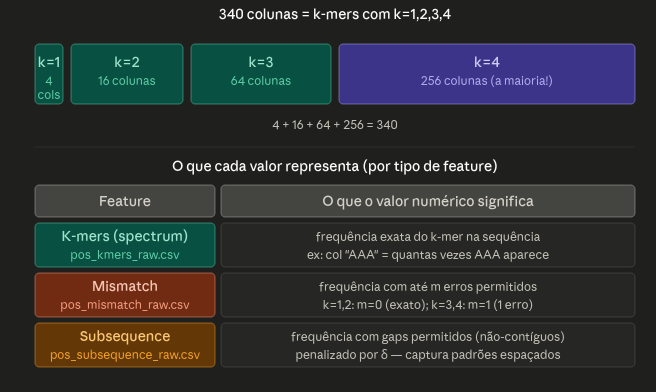

### EDA


#### Médias pos e neg

In [ ]:

features = ['kmers', 'mismatch', 'subsequence']

colns_dist_met = {}
media_pos_metodo = {}
media_neg_metodo = {}
for feat in features:
    #calculo da media para cada feature e dividindo entre pos e neg
    media_pos = train_data[feat]['pos'].mean(axis=0)
    media_neg = train_data[feat]['neg'].mean(axis=0)

    #diff real
    diff = media_pos - media_neg

    # valor abs da diferença e ordenar do maior para o menor
    diff_series = pd.Series(diff)
    colunas_ordenadas = diff_series.abs().sort_values(ascending=False)

    #armazena no dict
    colns_dist_met[feat] = colunas_ordenadas
    media_pos_metodo[feat] = media_pos
    media_neg_metodo[feat] = media_neg

#exibição dos 10 piores resultadores
for feat in features:
    print(f"\n" + "="*50)
    print(f"MÉTODO: {feat.upper()}")
    print(f"Índices das colunas com maior diferença de comportamento (Top 10):")
    print("="*50)


    top_10 = colns_dist_met[feat].head(10)

    for idx, valor_diff in top_10.items():
        print(f"Coluna {idx:3d}  ->  Diferença Absoluta Média: {valor_diff:.5f}")


MÉTODO: KMERS
Índices das colunas com maior diferença de comportamento (Top 10):
Coluna   2  ->  Diferença Absoluta Média: 0.04783
Coluna   1  ->  Diferença Absoluta Média: 0.03300
Coluna  18  ->  Diferença Absoluta Média: 0.03271
Coluna   0  ->  Diferença Absoluta Média: 0.02532
Coluna  14  ->  Diferença Absoluta Média: 0.02237
Coluna  15  ->  Diferença Absoluta Média: 0.02195
Coluna   4  ->  Diferença Absoluta Média: 0.01824
Coluna  78  ->  Diferença Absoluta Média: 0.01652
Coluna   9  ->  Diferença Absoluta Média: 0.01586
Coluna  19  ->  Diferença Absoluta Média: 0.01412

MÉTODO: MISMATCH
Índices das colunas com maior diferença de comportamento (Top 10):
Coluna  14  ->  Diferença Absoluta Média: 3.40113
Coluna   2  ->  Diferença Absoluta Média: 1.98730
Coluna  62  ->  Diferença Absoluta Média: 1.86872
Coluna  12  ->  Diferença Absoluta Média: 1.83090
Coluna  18  ->  Diferença Absoluta Média: 1.83009
Coluna  78  ->  Diferença Absoluta Média: 1.78417
Coluna   6  ->  Diferença Absolut

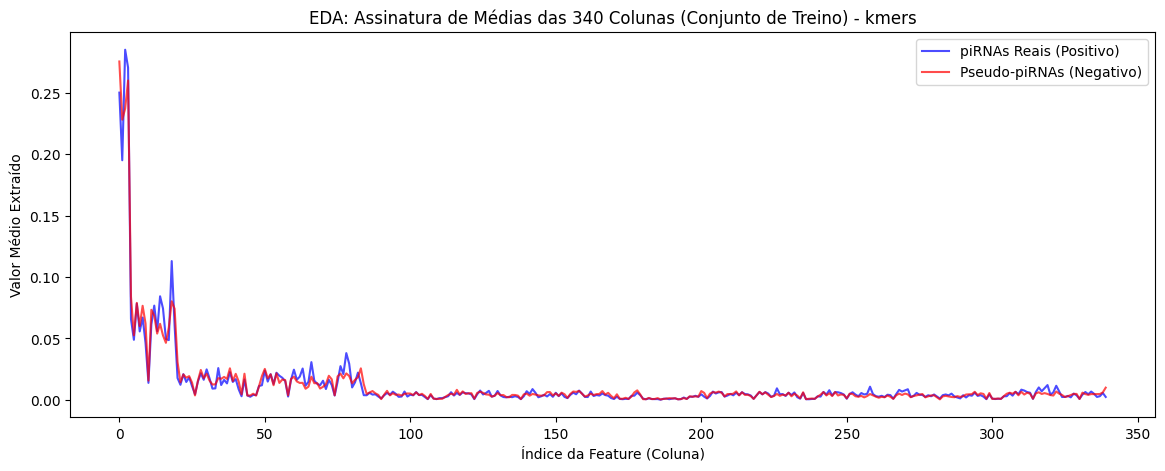

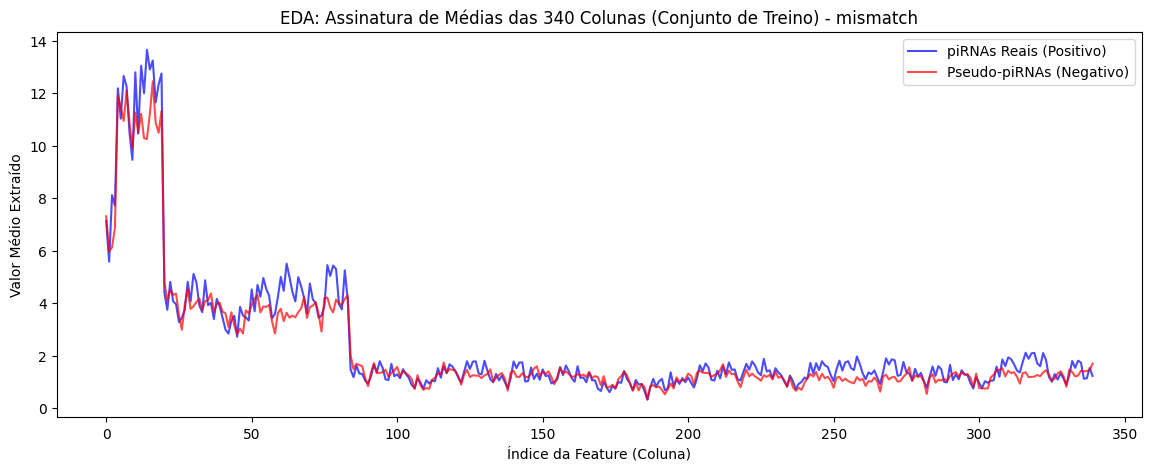

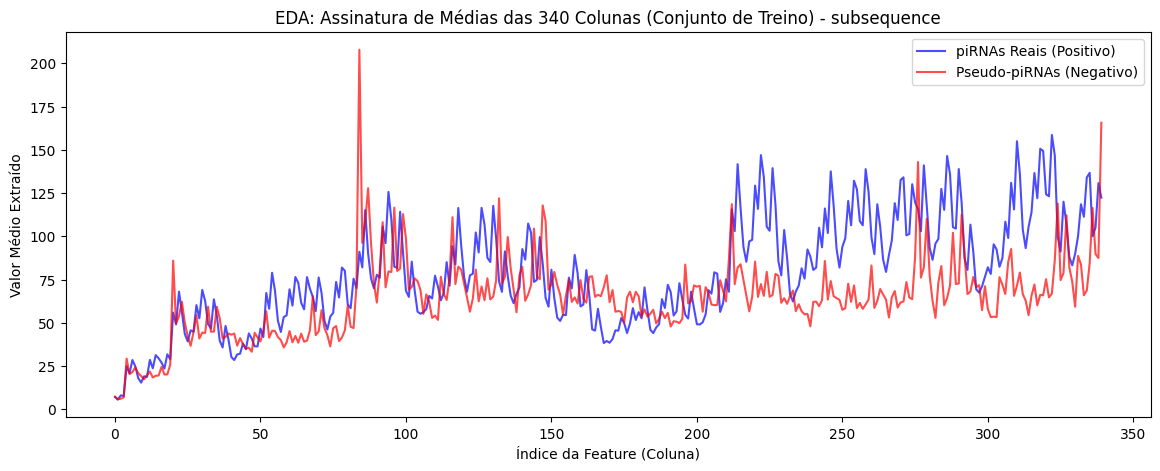

In [ ]:
#usando o dict media pos e neg
#plotando media pos x media 5jkddc5
for feat in features:
  plt.figure(figsize=(14, 5))
  plt.plot(media_pos_metodo[feat], label='piRNAs Reais (Positivo)', color='blue', alpha=0.7)
  plt.plot(media_neg_metodo[feat], label='Pseudo-piRNAs (Negativo)', color='red', alpha=0.7)
  plt.title(f'EDA: Assinatura de Médias das 340 Colunas (Conjunto de Treino) - {feat}')
  plt.xlabel('Índice da Feature (Coluna)')
  plt.ylabel('Valor Médio Extraído')
  plt.legend()
  plt.show()

precisaremos normalizar os dados pois temos uma escala que varia de 0.0Y ate 200.





#### Boxplot

In [ ]:
# mapeia índice numérico (0 a 339) para o motivo biológico real (A, C, G, T...)
def obter_nome(indice):
    bases = ['A', 'C', 'G', 'T']
    # k=1 (4 colunas: 0 a 3)
    if indice < 4:
        return bases[indice]
    # k=2 (16 colunas: 4 a 19)
    elif indice < 20:
        idx = indice - 4
        return bases[idx // 4] + bases[idx % 4]
    # k=3 (64 colunas: 20 a 83)
    elif indice < 84:
        idx = indice - 20
        return bases[idx // 16] + bases[(idx // 4) % 4] + bases[idx % 4]
    # k=4 (256 colunas: 84 a 339)
    else:
        idx = indice - 84
        return bases[idx // 64] + bases[(idx // 16) % 4] + bases[(idx // 4) % 4] + bases[idx % 4]


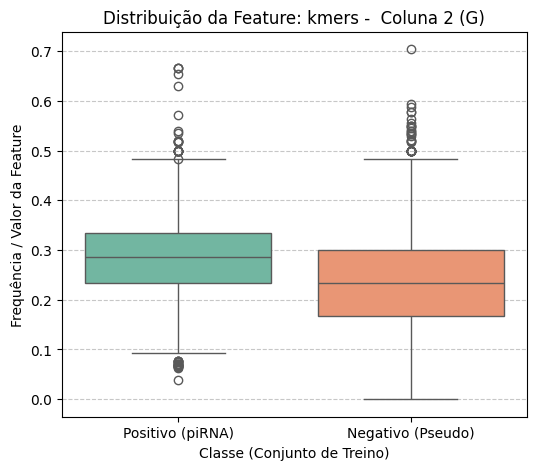

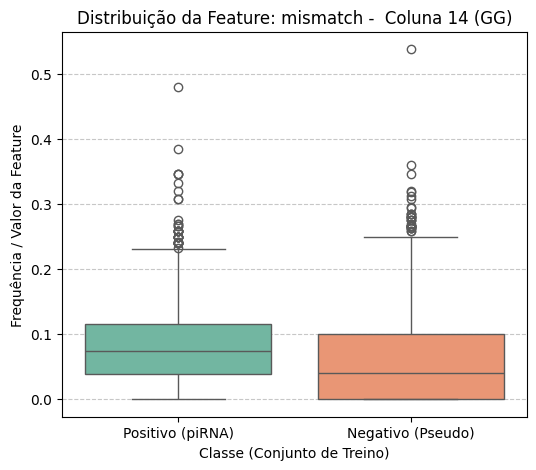

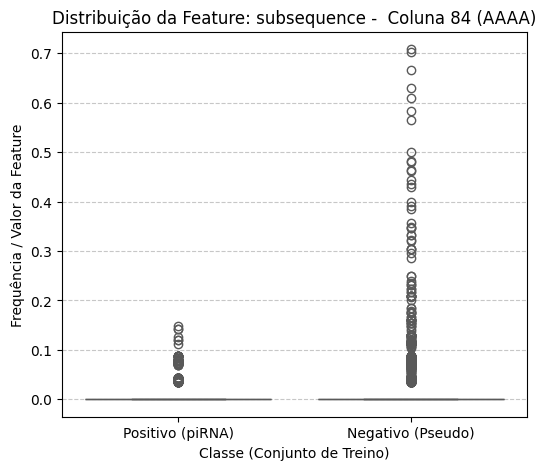

In [ ]:

for feat in features:
  #Definir a coluna com maior diferença
  coluna_alvo = colns_dist_met[feat].index[0]

  nome = obter_nome(coluna_alvo)

  # Preparar os dados para o Seaborn de forma robusta
  # df temporário para o plot
  dados_plot = pd.DataFrame({
      'Valor': pd.concat([train_data['kmers']['pos'][coluna_alvo], train_data['kmers']['neg'][coluna_alvo]]),
      'Classe': ['Positivo (piRNA)'] * len(train_data['kmers']['pos']) + ['Negativo (Pseudo)'] * len(train_data['kmers']['neg'])
  })

  #plota o Boxplot estruturado
  plt.figure(figsize=(6, 5))
  sns.boxplot(data=dados_plot, x='Classe', y='Valor',hue='Classe', palette='Set2', legend=False)


  plt.title(f'Distribuição da Feature: {feat} -  Coluna {coluna_alvo} ({nome})')
  plt.ylabel('Frequência / Valor da Feature')
  plt.xlabel('Classe (Conjunto de Treino)')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

### Modelo baseado na Combinação Única

#### Pré-Processamento do dados


utilizaremos a estratégia **Combinação Direta**, que consiste em agrupar todas as features -  1020 atributos. Esta será aplicada ao conjunto de treinamento e teste.

Ajuste de dados:
- combinação direta
- normalização
- junção dos rótulos - pos + neg  -> ([7404])
- ajuste de dimensão -> [7404,1]
- transformação do vetor de atributos em tensor

In [ ]:
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu" )
print(f"Rodando em: {device}")

Rodando em: cuda


In [ ]:
class Seleciona_Feature():
  def __init__( self, features, train_data, test_data, device):

    if isinstance(features, str):
      features = [features]

    pos_train_list, neg_train_list = [], []
    pos_test_list, neg_test_list = [], []

    for feat in features:
      #seleciona as features selecionadas
      pos_train_list.append(train_data[feat]['pos'])
      neg_train_list.append(train_data[feat]['neg'])
      pos_test_list.append(test_data[feat]['pos'])
      neg_test_list.append(test_data[feat]['neg'])

    pos_train_df = pd.concat(pos_train_list, axis=1)
    neg_train_df = pd.concat(neg_train_list, axis=1)
    pos_test_df = pd.concat(pos_test_list, axis=1)
    neg_test_df = pd.concat(neg_test_list, axis=1)


    # junção dos rotulos
    X_train_df = pd.concat([pos_train_df, neg_train_df], axis=0)
    X_test_df = pd.concat([pos_test_df, neg_test_df], axis=0)

    #Criação e ajuste de dimensão dos rótulos (y_train)
    y_train = torch.cat([torch.ones(len(pos_train_df)), torch.zeros(len(neg_train_df))]).unsqueeze(1)
    y_test = torch.cat([torch.ones(len(pos_test_df)), torch.zeros(len(neg_test_df))]).unsqueeze(1)

    #Normalização (StandardScaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df.values)
    X_test_scaled = scaler.transform(X_test_df.values)

    #Convertendo para Tensores e salvando
    self.X_train = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    self.y_train = y_train.to(device)

    self.X_test = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    self.y_test = y_test.to(device)


    print(f" Features Selecionadas: {features}")
    print(f"Formato X (Treino): {self.X_train.shape} | Alvo y (Treino): {self.y_train.shape}")
    print(f"Formato X (Teste) : {self.X_test.shape} | Alvo y (Teste) : {self.y_test.shape}")
    print("-" * 60)

  def get_data(self):
    return self.X_train, self.y_train, self.X_test, self.y_test

In [ ]:
data_comb_direta = Seleciona_Feature(['kmers','mismatch','subsequence'], train_data, test_data, device)
X_train, y_train, X_test, y_test = data_comb_direta.get_data()

 Features Selecionadas: ['kmers', 'mismatch', 'subsequence']
Formato X (Treino): torch.Size([7404, 1020]) | Alvo y (Treino): torch.Size([7404, 1])
Formato X (Teste) : torch.Size([7406, 1020]) | Alvo y (Teste) : torch.Size([7406, 1])
------------------------------------------------------------


#### Arquitetura da rede






##### Encoder+MLP

Configuração:
- Estrutura do Encoder: [ 512, 128]
- Estrutura da MLP:     [128, 64]
- Hiperparâmetros:      LR=0.001 | WD=0.01 | Dropout=0.6




In [ ]:
class Classifier_Enc( nn.Module ):
  def __init__( self, input_dim ):
    super( Classifier_Enc, self ).__init__()
    #encoder
    self.encoder = nn.Sequential(
        nn.Linear( input_dim, 512 ),
        nn.BatchNorm1d( 512 ),
        nn.ReLU(),
        nn.Dropout( 0.6 ),

        nn.Linear( 512, 128 ),
        nn.BatchNorm1d( 128 ),
        nn.ReLU(),
        nn.Dropout( 0.6 )
    )

    self.mlp = nn.Sequential(
        nn.Linear( 128, 64 ),
        nn.ReLU(),
        nn.Dropout( 0.6 ),

        nn.Linear( 64, 1 ),
        nn.Sigmoid()

    )
  def forward( self, x ):

    encoder = self.encoder( x )
    prob = self.mlp( encoder )

    return prob

##### MLP
Configuração:

    Estrutura da MLP:: [ 512, 256, 128, 64]
    Hiperparâmetros: LR=0.001 | WD=0.01 | Dropout=0.6


In [ ]:
#uma arquitetura sem o encoder

class Classifier_MLP( nn.Module ):
  def __init__( self, input_dim ):
    super( Classifier_MLP, self ).__init__()

    self.net = nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(64, 1),
        nn.Sigmoid()
    )

  def forward( self, x ):
    return self.net( x )

#### Instanciando o Modelo

##### modelo sem encoder



In [ ]:
#definindo a loss
loss = nn.BCELoss() #entropia cruzada binária

In [ ]:
#instanciando o modelo sem encoder
model = Classifier_MLP( input_dim = X_train.shape[ 1 ] )
model = model.to( device )

#instanciando o otimizador
optimizer = torch.optim.Adam( model.parameters(), lr = 0.001, weight_decay = 1.0e-2 )#colocando um weight decay que é uma regularização para evitar overfitting

print("--- Modelo Sem Encoder ---")
print(model)
print("\n" + "="*50 + "\n")

#veja que só tem um neuronio na camada de saída pq ele representa a probabilidade
#da amostra ser positiva

--- Modelo Sem Encoder ---
Classifier_MLP(
  (net): Sequential(
    (0): Linear(in_features=1020, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.6, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.6, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
    (17): Sigmoid()
  )
)




##### modelo com o encoder

In [ ]:
#Com decoder
model_enc = Classifier_Enc(input_dim=X_train.shape[1])
model_enc = model_enc.to(device)

#otimizador
optimizer_enc = torch.optim.Adam(model_enc.parameters(), lr = 0.001, weight_decay = 1.0e-2 )

print("--- Modelo Com Encoder ---")
print(model_enc)

--- Modelo Com Encoder ---
Classifier_Enc(
  (encoder): Sequential(
    (0): Linear(in_features=1020, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


#### Executando o modelo

In [ ]:
#configurações
epochs = 500
batch_size = 64 #treinar em batches

##### Modelo sem encoder

In [ ]:
# ARQUITETURA SEM ENCODER

train_loss = []
test_loss = []

for epoch in range( epochs ):
  model.train() #vai ativar o dropout e o batch norm

  shuffle_index = torch.randperm( X_train.size( 0 ) )
  X_shuffle = X_train[ shuffle_index ]
  y_shuffle = y_train[ shuffle_index ]

  cum_error = 0.0
  num_batches = 0

  #treinamnto em batches
  for i in range( 0, X_train.size( 0 ), batch_size ):
    #separa um batch
    X_batch = X_shuffle[ i : i + batch_size ].to( device )
    y_batch = y_shuffle[ i : i + batch_size ].to( device )

    optimizer.zero_grad()#zera os gradientes

    preds = model( X_batch ) #forward pass

    error = loss( preds, y_batch )#calcula a loss

    error.backward() #calcula como ajustar os pesos

    optimizer.step()#faz a atualização efetivamente

    cum_error += error.item()
    num_batches += 1

  mean_train_error = cum_error / num_batches
  train_loss.append( mean_train_error )

  #teste
  model.eval()#desativa o dropout e batch norm
  with torch.no_grad():
    test_preds = model( X_test )
    test_error = loss( test_preds, y_test )
    test_loss.append( test_error.item() )

  # Print a cada 10 épocas
  if (epoch + 1) % 10 == 0:
      print(f"Sem Enc | Época [{epoch + 1}/{epochs}] | Treino Loss: {mean_train_error:.4f} | Teste Loss: {test_error.item():.4f}")


Sem Enc | Época [10/500] | Treino Loss: 0.4235 | Teste Loss: 0.5467
Sem Enc | Época [20/500] | Treino Loss: 0.4269 | Teste Loss: 0.5393
Sem Enc | Época [30/500] | Treino Loss: 0.4141 | Teste Loss: 0.4987
Sem Enc | Época [40/500] | Treino Loss: 0.4041 | Teste Loss: 0.5056
Sem Enc | Época [50/500] | Treino Loss: 0.4056 | Teste Loss: 0.5112
Sem Enc | Época [60/500] | Treino Loss: 0.4003 | Teste Loss: 0.5297
Sem Enc | Época [70/500] | Treino Loss: 0.4049 | Teste Loss: 0.5107
Sem Enc | Época [80/500] | Treino Loss: 0.3935 | Teste Loss: 0.5215
Sem Enc | Época [90/500] | Treino Loss: 0.3942 | Teste Loss: 0.5027
Sem Enc | Época [100/500] | Treino Loss: 0.3967 | Teste Loss: 0.5185
Sem Enc | Época [110/500] | Treino Loss: 0.3977 | Teste Loss: 0.5315
Sem Enc | Época [120/500] | Treino Loss: 0.3924 | Teste Loss: 0.5312
Sem Enc | Época [130/500] | Treino Loss: 0.4003 | Teste Loss: 0.5478
Sem Enc | Época [140/500] | Treino Loss: 0.3927 | Teste Loss: 0.5318
Sem Enc | Época [150/500] | Treino Loss: 0.

##### Modelo com encoder

In [ ]:
# Arquitetura com encoder
train_loss_enc = []
test_loss_enc = []
for epoch in range( epochs ):
  model_enc.train()

  shuffle_index = torch.randperm( X_train.size( 0 ) )
  X_shuffle = X_train[ shuffle_index ]
  y_shuffle = y_train[ shuffle_index ]

  cum_error = 0.0
  num_batches = 0

  #treinamnto em batches
  for i in range( 0, X_train.size( 0 ), batch_size ):
    #separa um batch
    X_batch = X_shuffle[ i : i + batch_size ].to( device )
    y_batch = y_shuffle[ i : i + batch_size ].to( device )

    optimizer_enc.zero_grad()#zera os gradientes

    preds = model_enc( X_batch ) #forward pass

    error = loss( preds, y_batch )

    error.backward() #calcula como ajustar os pesos

    optimizer_enc.step()#faz a atualização efetivamente

    cum_error += error.item()
    num_batches += 1

  mean_train_error = cum_error / num_batches
  train_loss_enc.append( mean_train_error )

  #teste
  model_enc.eval()#desativa o dropout e batch norm
  with torch.no_grad():
    test_preds_enc = model_enc( X_test )
    test_error_enc = loss( test_preds_enc, y_test )
    test_loss_enc.append( test_error_enc.item() )

  # Print a cada 10 épocas
  if (epoch + 1) % 10 == 0:
      print(f"Com Enc | Época [{epoch + 1}/{epochs}] | Treino Loss: {mean_train_error:.4f} | Teste Loss: {test_error_enc.item():.4f}")


Com Enc | Época [10/500] | Treino Loss: 0.4116 | Teste Loss: 0.5305
Com Enc | Época [20/500] | Treino Loss: 0.4076 | Teste Loss: 0.4991
Com Enc | Época [30/500] | Treino Loss: 0.3982 | Teste Loss: 0.5455
Com Enc | Época [40/500] | Treino Loss: 0.3912 | Teste Loss: 0.5242
Com Enc | Época [50/500] | Treino Loss: 0.3872 | Teste Loss: 0.5196
Com Enc | Época [60/500] | Treino Loss: 0.3893 | Teste Loss: 0.5351
Com Enc | Época [70/500] | Treino Loss: 0.3804 | Teste Loss: 0.5157
Com Enc | Época [80/500] | Treino Loss: 0.3752 | Teste Loss: 0.5599
Com Enc | Época [90/500] | Treino Loss: 0.3901 | Teste Loss: 0.5306
Com Enc | Época [100/500] | Treino Loss: 0.3719 | Teste Loss: 0.5539
Com Enc | Época [110/500] | Treino Loss: 0.3791 | Teste Loss: 0.5460
Com Enc | Época [120/500] | Treino Loss: 0.3826 | Teste Loss: 0.5251
Com Enc | Época [130/500] | Treino Loss: 0.3790 | Teste Loss: 0.5543
Com Enc | Época [140/500] | Treino Loss: 0.3730 | Teste Loss: 0.5381
Com Enc | Época [150/500] | Treino Loss: 0.

#### Avaliação

##### Sem encoder

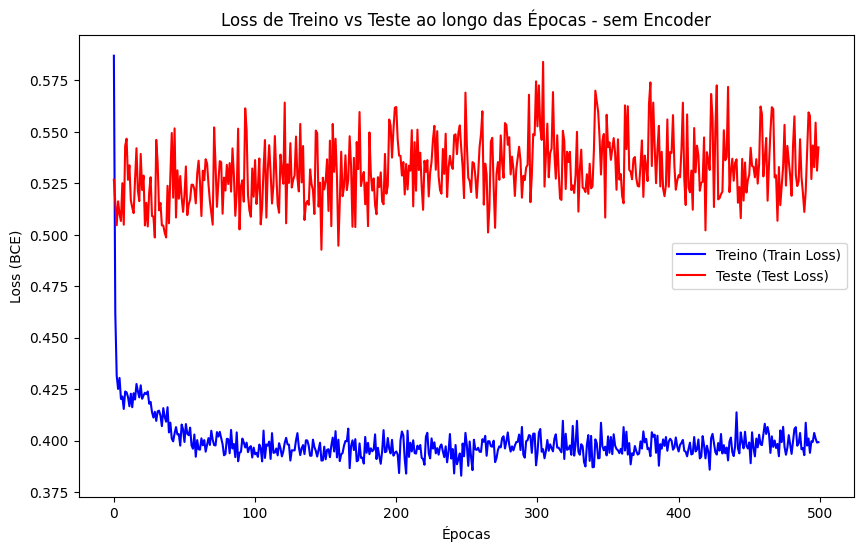

In [ ]:
plt.figure( figsize = ( 10, 6 ) )

plt.plot( train_loss, label = 'Treino (Train Loss)', color = 'blue' )
plt.plot( test_loss, label = 'Teste (Test Loss)', color = 'red' )

plt.title( 'Loss de Treino vs Teste ao longo das Épocas - sem Encoder' )
plt.xlabel( 'Épocas' )
plt.ylabel( 'Loss (BCE)' )
plt.legend()

plt.show()

In [ ]:
#travando o modelo para avaliação (desativa dropout e barchnorm)
model.eval()

with torch.no_grad():
    #todos os dados de teste de uma vez
    test_pred = model( X_test )

    # >= 0.5 vira 1 (Positivo), < 0.5 vira 0 (Negativo)
    binary_pred = ( test_pred >= 0.5 ).float()

    #comopara as previsões com os labels (y_test)
    correct_pred = ( binary_pred == y_test ).sum().item()
    total_samples = y_test.size( 0 )

    acuracia = ( correct_pred / total_samples ) * 100
    f1 = f1_score( y_test.cpu(), binary_pred.cpu() )

print(f"Acurácia no conjunto de teste: {acuracia:.2f}%")
print(f"F1 Score no conjunto de teste: {f1:.2f}%")


Acurácia no conjunto de teste: 71.89%
F1 Score no conjunto de teste: 0.68%


com encoder


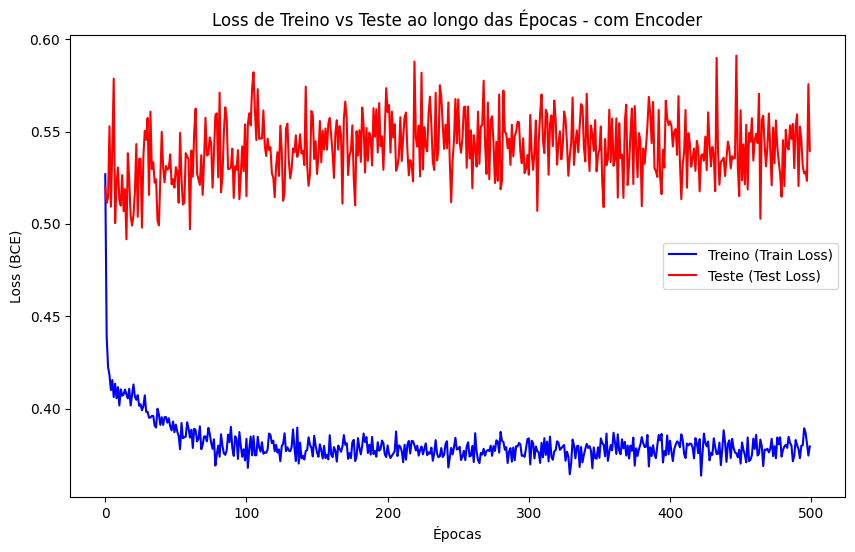

In [ ]:
plt.figure( figsize = ( 10, 6 ) )

plt.plot( train_loss_enc, label = 'Treino (Train Loss)', color = 'blue' )
plt.plot( test_loss_enc, label = 'Teste (Test Loss)', color = 'red' )

plt.title( 'Loss de Treino vs Teste ao longo das Épocas - com Encoder' )
plt.xlabel( 'Épocas' )
plt.ylabel( 'Loss (BCE)' )
plt.legend()

plt.show()

In [ ]:
#travando o modelo para avaliação (desativa dropout e barchnorm)
model_enc.eval()

with torch.no_grad():
    #todos os dados de teste de uma vez
    test_pred = model_enc( X_test )

    # >= 0.5 vira 1 (Positivo), < 0.5 vira 0 (Negativo)
    binary_pred = ( test_pred >= 0.5 ).float()

    #comopara as previsões com os labels (y_test)
    correct_pred = ( binary_pred == y_test ).sum().item()
    total_samples = y_test.size( 0 )

    acuracia = ( correct_pred / total_samples ) * 100
    f1 = f1_score( y_test.cpu(), binary_pred.cpu() )

print(f"Acurácia no conjunto de teste: {acuracia:.2f}%")
print(f"F1 Score no conjunto de teste: {f1:.2f}%")

Acurácia no conjunto de teste: 73.67%
F1 Score no conjunto de teste: 0.72%


##### Discussão
Observando as duas arquiteturas, podemos observar pela acurácia+f1 e pelo gráfico que a arquitetura encoder+mlp obteve um melhor desempenho para set de Combinação Única.

## Modelo Baseado em Características Individuais


### Configurações

In [ ]:
class FeatClassifier:
  def __init__(self, X_train, y_train, X_test, y_test,
               model_class, device, lr=0.001, weight_decay=1e-2, l1_lambda=1e-4,
               epochs=500, batch_size=64, model_name='class_enc'):
    self.X_train = X_train
    self.y_train = y_train
    self.X_test = X_test
    self.y_test = y_test

    self.device = device
    self.epochs = epochs
    self.batch_size = batch_size
    self.l1_lambda = l1_lambda
    self.model_name = model_name

    self.model = model_class(
            input_dim=X_train.shape[1]
        ).to(device)

    self.criterion = nn.BCELoss()

    self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    self.train_losses = []
    self.test_losses = []

    self.best_test_loss = float("inf")
    self.best_epoch = 0

    print("Modelo Criado:")
    print(self.model)

  def train(self):

      for epoch in range(self.epochs):
        self.model.train()

        shuffle_index = torch.randperm(self.X_train.size(0))
        X_shuffle = self.X_train[shuffle_index]
        y_shuffle = self.y_train[shuffle_index]

        cum_error = 0.0

        for i in range(0, self.X_train.size(0), self.batch_size):
            X_batch = X_shuffle[i:i+self.batch_size]
            y_batch = y_shuffle[i:i+self.batch_size]

            self.optimizer.zero_grad()
            preds = self.model(X_batch)

            error = self.criterion(preds, y_batch)

            #penalidade L1 (soma absoluta de todos os pesos)
            l1_norm = sum(p.abs().sum() for p in self.model.parameters())

            #add a penalidade à Loss final
            loss = error + (self.l1_lambda * l1_norm)

            # o backward na loss regularizada
            loss.backward()
            self.optimizer.step()

            cum_error += error.item() # Guardamos apenas o erro puro para o gráfico

        mean_train_error = cum_error / (self.X_train.size(0) / self.batch_size)
        self.train_losses.append(mean_train_error)

        self.model.eval()

        with torch.no_grad():

              test_preds = self.model(self.X_test)

              test_loss = self.criterion(test_preds,self.y_test)

              self.test_losses.append(test_loss.item())

              if test_loss.item() < self.best_test_loss:

                self.best_test_loss = (test_loss.item())
                self.best_epoch = epoch + 1

                torch.save(self.model.state_dict(),f"{self.model_name}.pth")

        if (epoch + 1) % 10 == 0:

                print(
                    f"Época [{epoch+1}/{self.epochs}] "
                    f"| Train Loss: {mean_train_error:.4f} "
                    f"| Test Loss: {test_loss.item():.4f}"
                )

  def evaluate(self):

        self.model.load_state_dict(
            torch.load(
                f"{self.model_name}.pth",
                map_location=self.device
            )
        )

        self.model.eval()

        with torch.no_grad():

            predictions = (
                self.model(self.X_test) >= 0.5
            ).float()

            correct = (
                predictions == self.y_test
            ).sum().item()

            accuracy = (
                correct /
                self.y_test.size(0)
            ) * 100

            # Calculando o F1-Score (movendo os dados para a CPU)
            f1 = f1_score(
                self.y_test.cpu(),
                predictions.cpu()
            )
        print(
            f"\nMelhor época: {self.best_epoch}"
        )

        print(
            f"Acurácia final: {accuracy:.2f}%"
        )
        print(
        f"F1 Score final: {f1:.4f}"
        )

        return accuracy, f1



  def plot_losses(self, title="Curva de Loss"):

        plt.figure(figsize=(8, 5))

        plt.plot(
            self.train_losses,
            label="Treino",
            color="blue"
        )

        plt.plot(
            self.test_losses,
            label="Teste",
            color="red"
        )

        plt.axvline(
            x=self.best_epoch - 1,
            color="green",
            linestyle="--",
            label=f"Melhor Época ({self.best_epoch})"
        )

        plt.title(title)
        plt.xlabel("Épocas")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        plt.show()


### Feature: K-mers

com encoder

 Features Selecionadas: ['kmers']
Formato X (Treino): torch.Size([7404, 340]) | Alvo y (Treino): torch.Size([7404, 1])
Formato X (Teste) : torch.Size([7406, 340]) | Alvo y (Teste) : torch.Size([7406, 1])
------------------------------------------------------------
Modelo Criado:
Classifier_Enc(
  (encoder): Sequential(
    (0): Linear(in_features=340, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Época [10/500] | Train Loss: 0.4402 | Te

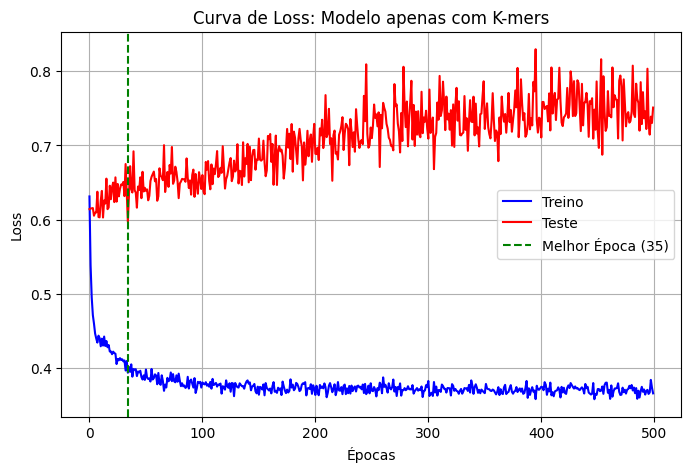

In [ ]:
feat = ['kmers']

data_individual = Seleciona_Feature(
    feat,
    train_data,
    test_data,
    device
)

X_train, y_train, X_test, y_test = (
    data_individual.get_data()
)

trainer = FeatClassifier(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_class=Classifier_Enc,
    device=device,
    epochs=500,
    batch_size=64,
    model_name=f"melhor_model_enc_{feat}"
)

trainer.train()

acc = trainer.evaluate()

trainer.plot_losses(
    title="Curva de Loss: Modelo apenas com K-mers"
)

sem encoder

 Features Selecionadas: ['kmers']
Formato X (Treino): torch.Size([7404, 340]) | Alvo y (Treino): torch.Size([7404, 1])
Formato X (Teste) : torch.Size([7406, 340]) | Alvo y (Teste) : torch.Size([7406, 1])
------------------------------------------------------------
Modelo Criado:
Classifier_MLP(
  (net): Sequential(
    (0): Linear(in_features=340, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.6, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True

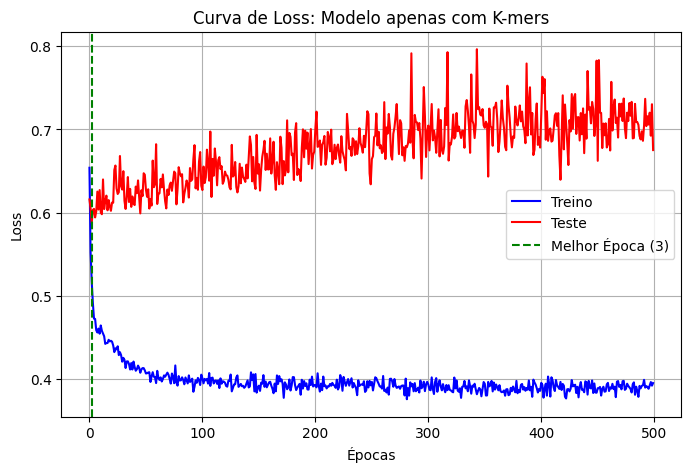

In [ ]:
feat = ['kmers']

data_individual = Seleciona_Feature(
    feat,
    train_data,
    test_data,
    device
)

X_train, y_train, X_test, y_test = (
    data_individual.get_data()
)

trainer = FeatClassifier(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_class=Classifier_MLP,
    device=device,
    epochs=500,
    batch_size=64,
    model_name=f"melhor_model_MLP_{feat}"
)

trainer.train()

acc = trainer.evaluate()

trainer.plot_losses(
    title="Curva de Loss: Modelo apenas com K-mers"
)

### Feature: Mismatch

 Features Selecionadas: ['mismatch']
Formato X (Treino): torch.Size([7404, 340]) | Alvo y (Treino): torch.Size([7404, 1])
Formato X (Teste) : torch.Size([7406, 340]) | Alvo y (Teste) : torch.Size([7406, 1])
------------------------------------------------------------
Modelo Criado:
Classifier_Enc(
  (encoder): Sequential(
    (0): Linear(in_features=340, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Época [10/500] | Train Loss: 0.4143 |

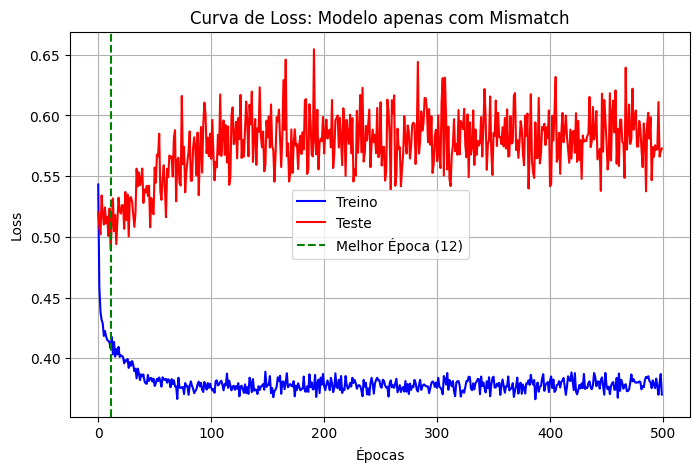

In [ ]:
feat = ['mismatch']

data_individual = Seleciona_Feature(
    feat,
    train_data,
    test_data,
    device
)

X_train, y_train, X_test, y_test = (
    data_individual.get_data()
)

trainer = FeatClassifier(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_class=Classifier_Enc,
    device=device,
    epochs=500,
    batch_size=64,
    model_name=f"melhor_model_enc_{feat}"
)

trainer.train()

acc = trainer.evaluate()

trainer.plot_losses(
    title="Curva de Loss: Modelo apenas com Mismatch"
)

 Features Selecionadas: ['mismatch']
Formato X (Treino): torch.Size([7404, 340]) | Alvo y (Treino): torch.Size([7404, 1])
Formato X (Teste) : torch.Size([7406, 340]) | Alvo y (Teste) : torch.Size([7406, 1])
------------------------------------------------------------
Modelo Criado:
Classifier_MLP(
  (net): Sequential(
    (0): Linear(in_features=340, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.6, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=T

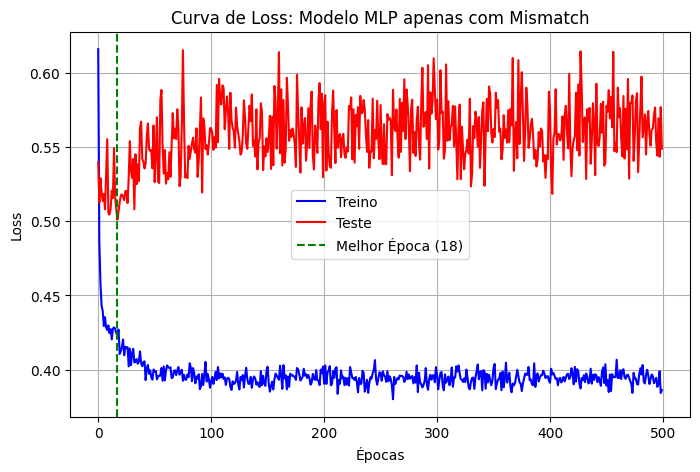

In [ ]:
feat = ['mismatch']

data_individual = Seleciona_Feature(
    feat,
    train_data,
    test_data,
    device
)

X_train, y_train, X_test, y_test = (
    data_individual.get_data()
)

trainer = FeatClassifier(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_class=Classifier_MLP,
    device=device,
    epochs=500,
    batch_size=64,
    model_name=f"melhor_model_enc_{feat}"
)

trainer.train()

acc = trainer.evaluate()

trainer.plot_losses(
    title="Curva de Loss: Modelo MLP apenas com Mismatch"
)

### Feature: Subsequence

 Features Selecionadas: ['subsequence']
Formato X (Treino): torch.Size([7404, 340]) | Alvo y (Treino): torch.Size([7404, 1])
Formato X (Teste) : torch.Size([7406, 340]) | Alvo y (Teste) : torch.Size([7406, 1])
------------------------------------------------------------
Modelo Criado:
Classifier_Enc(
  (encoder): Sequential(
    (0): Linear(in_features=340, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Época [10/500] | Train Loss: 0.471

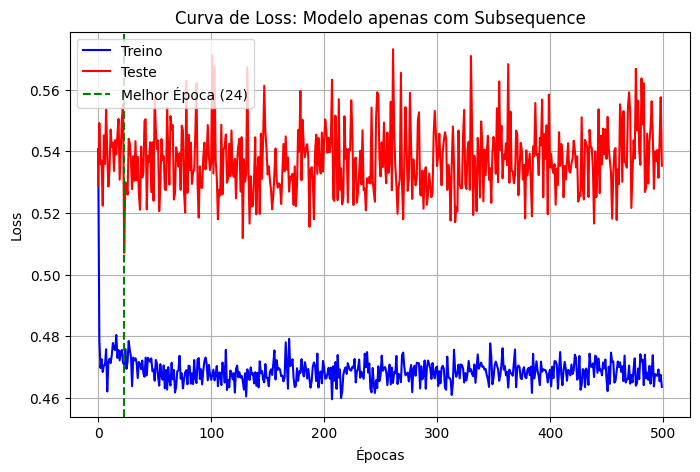

In [ ]:
feat = ['subsequence']

data_individual = Seleciona_Feature(
    feat,
    train_data,
    test_data,
    device
)

X_train, y_train, X_test, y_test = (
    data_individual.get_data()
)

trainer = FeatClassifier(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_class=Classifier_Enc,
    device=device,
    epochs=500,
    batch_size=64,
    model_name=f"melhor_model_enc_{feat}"
)

trainer.train()

acc = trainer.evaluate()

trainer.plot_losses(
    title="Curva de Loss: Modelo apenas com Subsequence"
)

 Features Selecionadas: ['subsequence']
Formato X (Treino): torch.Size([7404, 340]) | Alvo y (Treino): torch.Size([7404, 1])
Formato X (Teste) : torch.Size([7406, 340]) | Alvo y (Teste) : torch.Size([7406, 1])
------------------------------------------------------------
Modelo Criado:
Classifier_Enc(
  (encoder): Sequential(
    (0): Linear(in_features=340, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Época [10/500] | Train Loss: 0.471

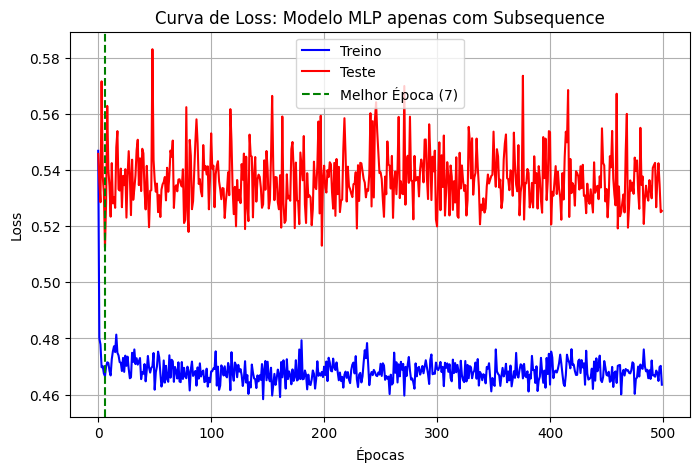

In [ ]:
feat = ['subsequence']

data_individual = Seleciona_Feature(
    feat,
    train_data,
    test_data,
    device
)

X_train, y_train, X_test, y_test = (
    data_individual.get_data()
)

trainer = FeatClassifier(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_class=Classifier_Enc,
    device=device,
    epochs=500,
    batch_size=64,
    model_name=f"melhor_model_MLP_{feat}"
)

trainer.train()

acc = trainer.evaluate()

trainer.plot_losses(
    title="Curva de Loss: Modelo MLP apenas com Subsequence"
)

### Discussão



# Teste com Redução de dimensionalidade

Aqui utiliza-se PCA para redução de dimensionalidade considerando a feature mismatch e fixando 95% de variância explicada, e também há a comparação com outros classificadores (Regressão Logística e SVM Linear):

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


In [ ]:
# =====================================================
# DADOS
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ---------------------------
# MISMATCH
# ---------------------------

pos_train_df = train_data['subsequence']['pos']
neg_train_df = train_data['subsequence']['neg']

pos_test_df = test_data['subsequence']['pos']
neg_test_df = test_data['subsequence']['neg']

X_train_df = pd.concat(
    [pos_train_df, neg_train_df],
    axis=0,
    ignore_index=True
)

X_test_df = pd.concat(
    [pos_test_df, neg_test_df],
    axis=0,
    ignore_index=True
)

y_train_np = np.concatenate([
    np.ones(len(pos_train_df)),
    np.zeros(len(neg_train_df))
])

y_test_np = np.concatenate([
    np.ones(len(pos_test_df)),
    np.zeros(len(neg_test_df))
])

Device: cuda


In [ ]:
# =====================================================
# PADRONIZAÇÃO
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

In [ ]:
# =====================================================
# PCA
# =====================================================

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\n===== PCA =====")
print("Dimensão original:", X_train_scaled.shape[1])
print("Dimensão reduzida:", X_train_pca.shape[1])
print(
    "Variância explicada:",
    pca.explained_variance_ratio_.sum()
)


===== PCA =====
Dimensão original: 340
Dimensão reduzida: 60
Variância explicada: 0.9505908767872906


In [ ]:
# =====================================================
# REGRESSÃO LOGÍSTICA
# =====================================================

print("\nTreinando Regressão Logística...")

reglog = LogisticRegression(
    max_iter=5000,
    n_jobs=-1
)

reglog.fit(
    X_train_pca,
    y_train_np
)

pred_reglog = reglog.predict(X_test_pca)

acc_reglog = accuracy_score(
    y_test_np,
    pred_reglog
)

print(
    f"Acurácia RegLog: {100*acc_reglog:.2f}%"
)


Treinando Regressão Logística...
Acurácia RegLog: 71.16%


In [ ]:
# =====================================================
# SVM LINEAR
# =====================================================

print("\nTreinando SVM Linear...")

svm = LinearSVC(
    C=1.0,
    max_iter=10000
)

svm.fit(
    X_train_pca,
    y_train_np
)

pred_svm = svm.predict(X_test_pca)

acc_svm = accuracy_score(
    y_test_np,
    pred_svm
)

print(
    f"Acurácia SVM: {100*acc_svm:.2f}%"
)



Treinando SVM Linear...
Acurácia SVM: 71.09%


In [ ]:
# =====================================================
# TENSORES
# =====================================================

X_train = torch.tensor(
    X_train_pca,
    dtype=torch.float32
).to(device)

X_test = torch.tensor(
    X_test_pca,
    dtype=torch.float32
).to(device)

y_train = torch.tensor(
    y_train_np,
    dtype=torch.float32
).unsqueeze(1).to(device)

y_test = torch.tensor(
    y_test_np,
    dtype=torch.float32
).unsqueeze(1).to(device)

In [ ]:
# =====================================================
# REDE PEQUENA
# =====================================================

class SmallNet(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,32),
            nn.ReLU(),

            nn.Linear(32,16),
            nn.ReLU(),

            nn.Linear(16,1)

        )

    def forward(self,x):

        return self.net(x)

In [ ]:
# =====================================================
# MODELO
# =====================================================

model = SmallNet(
    X_train.shape[1]
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
# =====================================================
# TREINAMENTO
# =====================================================

epochs = 300

batch_size = 128

best_loss = np.inf
best_epoch = 0

train_losses = []
test_losses = []

for epoch in range(epochs):

    model.train()

    idx = torch.randperm(
        X_train.size(0)
    )

    Xs = X_train[idx]
    ys = y_train[idx]

    epoch_loss = 0

    for i in range(
        0,
        X_train.size(0),
        batch_size
    ):

        xb = Xs[i:i+batch_size]
        yb = ys[i:i+batch_size]

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(
            logits,
            yb
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / (
        X_train.size(0)/batch_size
    )

    train_losses.append(train_loss)

    model.eval()

    with torch.no_grad():

        logits_test = model(X_test)

        test_loss = criterion(
            logits_test,
            y_test
        )

        test_losses.append(
            test_loss.item()
        )

        if test_loss < best_loss:

            best_loss = test_loss

            best_epoch = epoch

            torch.save(
                model.state_dict(),
                "best_smallnet.pth"
            )

    if (epoch+1)%10 == 0:

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train={train_loss:.4f} | "
            f"Test={test_loss:.4f}"
        )

Epoch 010 | Train=0.3782 | Test=0.5751
Epoch 020 | Train=0.3377 | Test=0.6223
Epoch 030 | Train=0.3056 | Test=0.6600
Epoch 040 | Train=0.2817 | Test=0.7432
Epoch 050 | Train=0.2564 | Test=0.7902
Epoch 060 | Train=0.2380 | Test=0.8851
Epoch 070 | Train=0.2191 | Test=0.9356
Epoch 080 | Train=0.2062 | Test=0.9830
Epoch 090 | Train=0.1927 | Test=1.0900
Epoch 100 | Train=0.1816 | Test=1.1510
Epoch 110 | Train=0.1691 | Test=1.2296
Epoch 120 | Train=0.1598 | Test=1.3118
Epoch 130 | Train=0.1507 | Test=1.3496
Epoch 140 | Train=0.1412 | Test=1.3997
Epoch 150 | Train=0.1336 | Test=1.5486
Epoch 160 | Train=0.1290 | Test=1.5932
Epoch 170 | Train=0.1217 | Test=1.6327
Epoch 180 | Train=0.1155 | Test=1.8227
Epoch 190 | Train=0.1120 | Test=1.8431
Epoch 200 | Train=0.1057 | Test=1.9043
Epoch 210 | Train=0.0992 | Test=2.0374
Epoch 220 | Train=0.0979 | Test=2.1988
Epoch 230 | Train=0.0899 | Test=2.1369
Epoch 240 | Train=0.0928 | Test=2.2000
Epoch 250 | Train=0.0817 | Test=2.3025
Epoch 260 | Train=0.0810 

In [ ]:

# =====================================================
# MELHOR MODELO
# =====================================================

model.load_state_dict(
    torch.load(
        "best_smallnet.pth",
        map_location=device
    )
)

model.eval()

with torch.no_grad():

    logits = model(X_test)

    probs = torch.sigmoid(
        logits
    )

    pred_nn = (
        probs >= 0.5
    ).float()

    acc_nn = (
        pred_nn == y_test
    ).float().mean()

print("\n==============================")
print("RESULTADOS")
print("==============================")

print(
    f"Rede Neural : {100*acc_nn.item():.2f}%"
)

print(
    f"RegLog      : {100*acc_reglog:.2f}%"
)

print(
    f"SVM Linear  : {100*acc_svm:.2f}%"
)

print(
    f"Melhor época: {best_epoch+1}"
)



RESULTADOS
Rede Neural : 72.83%
RegLog      : 71.16%
SVM Linear  : 71.09%
Melhor época: 9


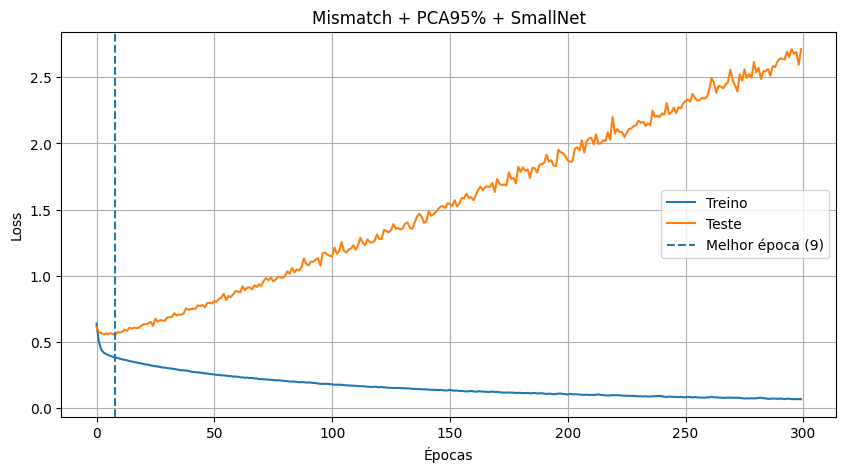

In [ ]:

# =====================================================
# GRÁFICO
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Treino"
)

plt.plot(
    test_losses,
    label="Teste"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Melhor época ({best_epoch+1})"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.title(
    "Mismatch + PCA95% + SmallNet"
)

plt.grid(True)

plt.legend()

plt.show()

# CNN nos dados brutos

Aqui usamos os dados brutos com uma rede convolucional que automatizará a extração de features internamente.

Com isso esperamos uma melhora com relação aos métodos anteriores por algum tipo de limitação ou perda de informação inerente aos descritores utilizados.

In [ ]:
# =====================================================
# CONFIGURAÇÕES
# =====================================================

caminho = '/content/drive/MyDrive/Redes Neurais/piRNAs/pirnet-main/data/raw/'

train_pos_file = caminho + "Human_pos_samples-training.fa"
train_neg_file = caminho + "Human_neg_samples-training.fa"

test_pos_file = caminho + "Human_pos_samples-test.fa"
test_neg_file = caminho + "Human_neg_samples-test.fa"

batch_size = 64

epochs = 200

learning_rate = 1e-3

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
# =====================================================
# LEITOR FASTA
# =====================================================

def read_fasta(filename):

    sequences = []

    current = ""

    with open(filename, "r") as f:

        for line in f:

            line = line.strip()

            if line.startswith(">"):

                if current != "":

                    sequences.append(
                        current.upper()
                    )

                    current = ""

            else:

                current += line

        if current != "":

            sequences.append(
                current.upper()
            )

    return sequences


In [ ]:
# =====================================================
# CARREGA DADOS
# =====================================================

train_pos = read_fasta(
    train_pos_file
)

train_neg = read_fasta(
    train_neg_file
)

test_pos = read_fasta(
    test_pos_file
)

test_neg = read_fasta(
    test_neg_file
)

In [ ]:
# =====================================================
# JUNTA TODOS
# =====================================================

all_pos = train_pos + test_pos

all_neg = train_neg + test_neg

X = all_pos + all_neg

y = (
    [1] * len(all_pos)
    +
    [0] * len(all_neg)
)

print("Positivos :", len(all_pos))
print("Negativos :", len(all_neg))
print("Total     :", len(X))


Positivos : 7405
Negativos : 7405
Total     : 14810


In [ ]:
# =====================================================
# COMPRIMENTO
# =====================================================

lengths = np.array([
    len(seq)
    for seq in X
])

max_len = lengths.max()

print(
    "Maior sequência:",
    max_len
)


Maior sequência: 33


In [ ]:

# =====================================================
# ENCODING
# =====================================================

mapping = {
    "A":0,
    "C":1,
    "G":2,
    "T":3,
    "U":3,
    "N":4
}

PAD_TOKEN = 5

def encode_sequence(seq):

    encoded = []

    for nt in seq:

        encoded.append(
            mapping.get(nt, 4)
        )

    if len(encoded) < max_len:

        encoded.extend(
            [PAD_TOKEN]
            *
            (max_len - len(encoded))
        )

    return encoded[:max_len]

X_encoded = np.array(
    [
        encode_sequence(seq)
        for seq in X
    ],
    dtype=np.int64
)

In [ ]:
# =====================================================
# NORMALIZA COMPRIMENTO
# =====================================================

lengths = lengths.astype(
    np.float32
)

lengths = (
    lengths /
    lengths.max()
)

y = np.array(y)


In [ ]:
# =====================================================
# NORMALIZA COMPRIMENTO
# =====================================================

lengths = lengths.astype(
    np.float32
)

lengths = (
    lengths /
    lengths.max()
)

y = np.array(y)


In [ ]:
# =====================================================
# TRAIN / VALIDATION / TEST
# =====================================================

(
    X_train_full,
    X_test,
    len_train_full,
    len_test,
    y_train_full,
    y_test
) = train_test_split(

    X_encoded,
    lengths,
    y,

    test_size=0.15,

    stratify=y,

    random_state=42
)

(
    X_train,
    X_val,
    len_train,
    len_val,
    y_train,
    y_val

) = train_test_split(

    X_train_full,
    len_train_full,
    y_train_full,

    test_size=0.1765,

    stratify=y_train_full,

    random_state=42
)

print()
print("Treino     :", len(X_train))
print("Validação  :", len(X_val))
print("Teste      :", len(X_test))



Treino     : 10366
Validação  : 2222
Teste      : 2222


In [ ]:
# =====================================================
# DATASET
# =====================================================

class PiRNADataset(Dataset):

    def __init__(
        self,
        X,
        lengths,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.long
        )

        self.lengths = torch.tensor(
            lengths,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.lengths[idx],
            self.y[idx]
        )


In [ ]:
# =====================================================
# DATASETS
# =====================================================

train_dataset = PiRNADataset(
    X_train,
    len_train,
    y_train
)

val_dataset = PiRNADataset(
    X_val,
    len_val,
    y_val
)

test_dataset = PiRNADataset(
    X_test,
    len_test,
    y_test
)

In [ ]:
# =====================================================
# DATALOADERS
# =====================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [ ]:
# =====================================================
# MODELO
# =====================================================

class PiRNACNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=6,
            embedding_dim=16,
            padding_idx=PAD_TOKEN
        )

        self.conv = nn.Sequential(

            nn.Conv1d(
                16,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.AdaptiveMaxPool1d(1)
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                129,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                1
            )
        )

    def forward(
        self,
        x,
        lengths
    ):

        x = self.embedding(x)

        x = x.permute(
            0,
            2,
            1
        )

        x = self.conv(x)

        x = x.squeeze(-1)

        lengths = lengths.unsqueeze(1)

        x = torch.cat(
            [x, lengths],
            dim=1
        )

        return self.classifier(x)

In [ ]:
# =====================================================
# MODELO
# =====================================================

model = PiRNACNN().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

model = PiRNACNN().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

In [ ]:
# =====================================================
# HISTÓRICO
# =====================================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_epoch = 0
best_loss = np.inf

patience = 20
counter = 0


In [ ]:
# =====================================================
# TREINAMENTO
# =====================================================

for epoch in range(epochs):

    # =================================================
    # TREINO
    # =================================================

    model.train()

    running_loss = 0

    train_preds = []
    train_truth = []

    for Xb, Lb, yb in train_loader:

        Xb = Xb.to(device)
        Lb = Lb.to(device)

        yb = yb.unsqueeze(1).to(device)

        optimizer.zero_grad()

        logits = model(
            Xb,
            Lb
        )

        loss = criterion(
            logits,
            yb
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(
            logits
        )

        preds = (
            probs > 0.5
        ).float()

        train_preds.extend(
            preds.cpu().numpy().flatten()
        )

        train_truth.extend(
            yb.cpu().numpy().flatten()
        )

    mean_train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = accuracy_score(
        train_truth,
        train_preds
    )

    # =================================================
    # VALIDAÇÃO
    # =================================================

    model.eval()

    running_loss = 0

    val_preds = []
    val_truth = []

    with torch.no_grad():

        for Xb, Lb, yb in val_loader:

            Xb = Xb.to(device)
            Lb = Lb.to(device)

            yb_gpu = (
                yb.unsqueeze(1)
                .to(device)
            )

            logits = model(
                Xb,
                Lb
            )

            loss = criterion(
                logits,
                yb_gpu
            )

            running_loss += loss.item()

            probs = torch.sigmoid(
                logits
            )

            preds = (
                probs > 0.5
            ).float()

            val_preds.extend(
                preds.cpu().numpy().flatten()
            )

            val_truth.extend(
                yb.numpy()
            )

    mean_val_loss = (
        running_loss /
        len(val_loader)
    )

    val_acc = accuracy_score(
        val_truth,
        val_preds
    )

    # =================================================
    # HISTÓRICO
    # =================================================

    train_losses.append(
        mean_train_loss
    )

    val_losses.append(
        mean_val_loss
    )

    train_accs.append(
        train_acc
    )

    val_accs.append(
        val_acc
    )

    # =================================================
    # EARLY STOPPING
    # =================================================

    if mean_val_loss < best_loss:

        best_loss = mean_val_loss

        best_epoch = epoch + 1

        counter = 0

        torch.save(
            model.state_dict(),
            "best_pirna_cnn.pth"
        )

    else:

        counter += 1

    # =================================================
    # LOG
    # =================================================

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1:03d}/{epochs} | "
            f"Train Loss={mean_train_loss:.4f} | "
            f"Val Loss={mean_val_loss:.4f} | "
            f"Train Acc={100*train_acc:.2f}% | "
            f"Val Acc={100*val_acc:.2f}%"
        )

    # =================================================
    # PARADA
    # =================================================

    if counter >= patience:

        print(
            f"\nEarly Stopping na época {epoch+1}"
        )

        break

Epoch 010/200 | Train Loss=0.3268 | Val Loss=0.4141 | Train Acc=86.37% | Val Acc=81.32%
Epoch 020/200 | Train Loss=0.2169 | Val Loss=0.4438 | Train Acc=91.39% | Val Acc=81.73%

Early Stopping na época 28


In [ ]:
# =====================================================
# CARREGA MELHOR MODELO
# =====================================================

model.load_state_dict(
    torch.load(
        "best_pirna_cnn.pth"
    )
)

<All keys matched successfully>

In [ ]:
# =====================================================
# TESTE FINAL
# =====================================================

model.eval()

test_preds = []
test_truth = []

test_loss = 0

with torch.no_grad():

    for Xb, Lb, yb in test_loader:

        Xb = Xb.to(device)
        Lb = Lb.to(device)

        yb_gpu = (
            yb.unsqueeze(1)
            .to(device)
        )

        logits = model(
            Xb,
            Lb
        )

        loss = criterion(
            logits,
            yb_gpu
        )

        test_loss += loss.item()

        probs = torch.sigmoid(
            logits
        )

        preds = (
            probs > 0.5
        ).float()

        test_preds.extend(
            preds.cpu().numpy().flatten()
        )

        test_truth.extend(
            yb.numpy()
        )

mean_test_loss = (
    test_loss /
    len(test_loader)
)

final_acc = accuracy_score(
    test_truth,
    test_preds
)

final_f1 = f1_score(
    test_truth,
    test_preds
)


In [ ]:
# =====================================================
# RESULTADOS
# =====================================================

print()
print("=" * 50)
print("TREINAMENTO CONCLUÍDO")
print("=" * 50)

print(
    f"Melhor época      : {best_epoch}"
)

print(
    f"Melhor val loss   : {best_loss:.4f}"
)

print(
    f"Test loss         : {mean_test_loss:.4f}"
)

print(
    f"Acurácia teste    : {100*final_acc:.2f}%"
)

print(
    f"F1 teste          : {100*final_f1:.2f}%"
)


TREINAMENTO CONCLUÍDO
Melhor época      : 8
Melhor val loss   : 0.3854
Test loss         : 0.3740
Acurácia teste    : 83.93%
F1 teste          : 84.31%


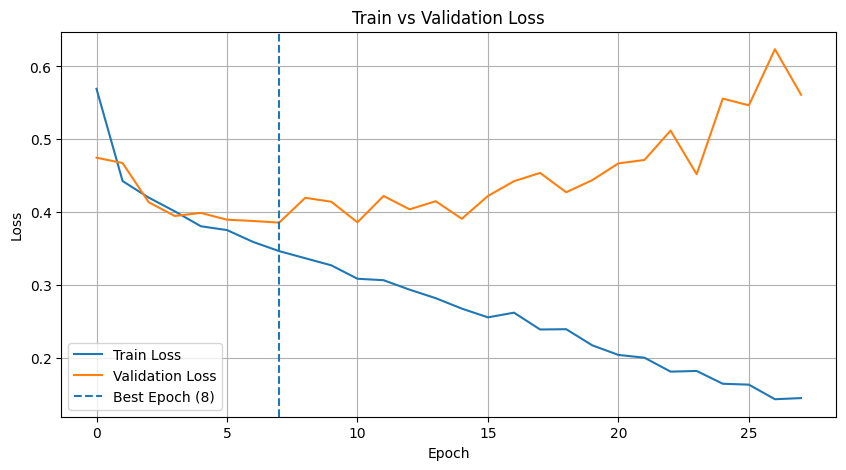

In [ ]:
# =====================================================
# LOSS
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Train vs Validation Loss"
)

plt.grid(True)

plt.legend()

plt.show()


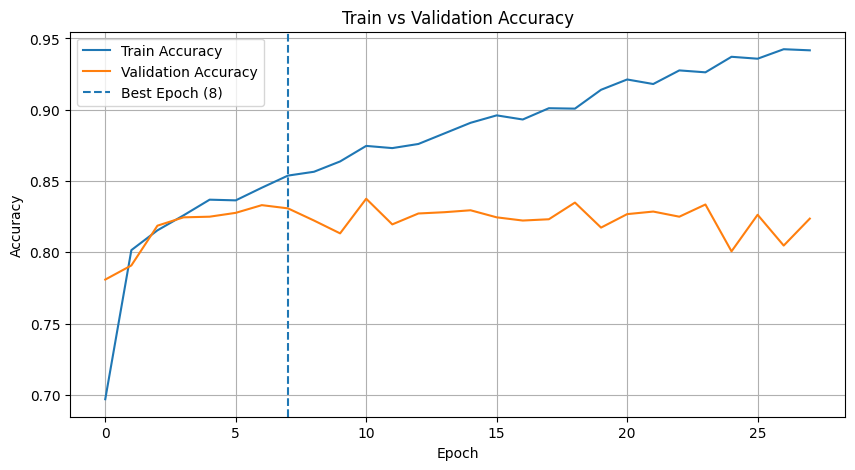

In [ ]:
# =====================================================
# ACCURACY
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Train vs Validation Accuracy"
)

plt.grid(True)

plt.legend()

plt.show()

Vemos que ao usar essa abordagem unido ao Early Stopping que evita a execução de muitas épocas quando a Loss no conjunto de teste não melhora, temos um modelo rápido e até então o mais efetivo até o momento, visto que não causou overfitting e atingiu 83.66% de acurácia.

# CNN com features

1.   Item da lista

1.   Item da lista
2.   Item da lista


2.   Item da lista



https://pmc.ncbi.nlm.nih.gov/articles/PMC6078063/


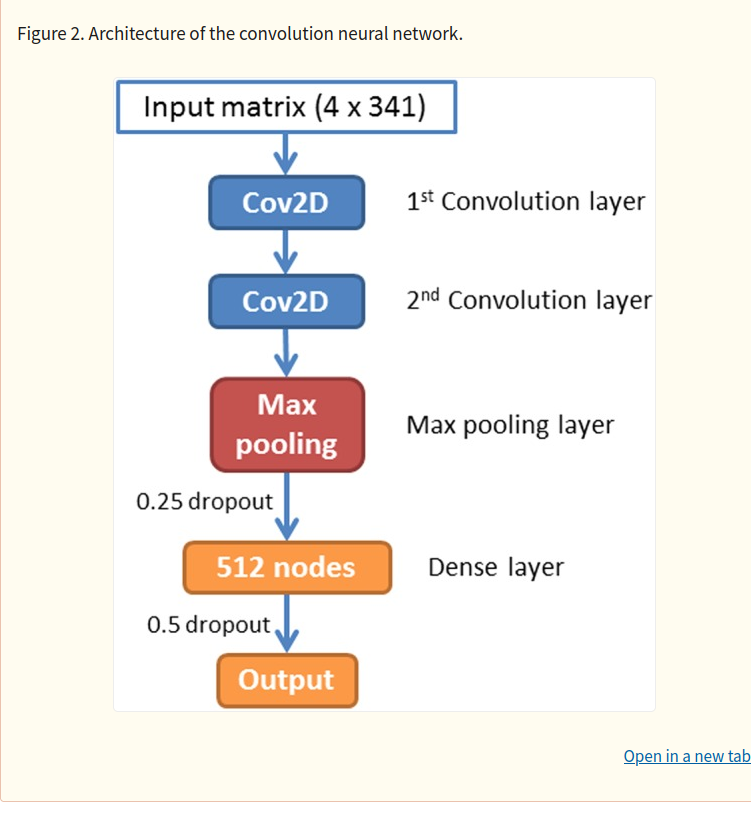

O autor original utilizou uma unica feature para classificar usando cnn, aqui irei testar com as 3 features

In [ ]:
#4*255 = 1020 colunas
linhas, colunas =  4, 340
input_shape = (linhas, colunas, 1)

nb_filters = 32
pool_size = (2, 2)
kernel_size = (2, 2)
kf_weights_path = 'best_model_pesos.keras'

In [ ]:
X_train_np = X_train
y_train_np = y_train

X_test_np = X_test
y_test_np = y_test

X_train_cnn = np.zeros(shape=(len(X_train), linhas, colunas, 1))
X_test_cnn = np.zeros(shape=(len(X_test), linhas, colunas, 1))



In [ ]:
#passa o vetor de 1020  para 4x255 por linha
for i in range(len(X_train_cnn)):
    tp = np.asarray(X_train_cnn[i])
    tp = np.resize(tp, (linhas, colunas, 1))
    X_train_cnn[i] = tp

for i in range(len(X_test_cnn)):
    tp = np.asarray(X_test_cnn[i])
    tp = np.resize(tp, (linhas, colunas, 1))
    X_test_cnn[i] = tp

In [ ]:
#instanciando o modelo
modelo = Sequential()

#primeira camada
modelo.add(Conv2D(nb_filters, kernel_size, padding='valid', input_shape=input_shape))
modelo.add(Activation('relu'))

#segunda camada
modelo.add(Conv2D(nb_filters, kernel_size))
modelo.add(Activation('relu'))
modelo.add(MaxPooling2D(pool_size=pool_size))
modelo.add(Dropout(0.25))

#camada densa
modelo.add(Flatten())
modelo.add(Dense(512))
modelo.add(Activation('relu'))
modelo.add(Dropout(0.5))

#camada de saida - 1 neuronio com sofmax para one hot
modelo.add(Dense(1))
modelo.add(Activation('sigmoid')) #alterei do original

modelo.compile(loss='binary_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy'])

# Callbacks de monitoramento do treino
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, verbose=1),
    ModelCheckpoint(kf_weights_path, monitor='val_loss', save_best_only=True, verbose=1)
]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#treinamento
modelo.fit(X_train_cnn, y_train_np, validation_data=(X_test_cnn, y_test_np), batch_size=32, epochs=150, callbacks=callbacks, verbose=1)

Epoch 1/150
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4934 - loss: 0.6932
Epoch 1: val_loss improved from None to 0.69315, saving model to best_model_pesos.keras

Epoch 1: finished saving model to best_model_pesos.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4959 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/150
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4976 - loss: 0.6932
Epoch 2: val_loss improved from 0.69315 to 0.69315, saving model to best_model_pesos.keras

Epoch 2: finished saving model to best_model_pesos.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4950 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/150
323/324 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5018 - loss: 0.6932
Epoch 3: val_loss improved from 0.69315 to 0.69315, saving model to best_model_pesos.keras

Epoch 3: finished saving model to best_model_pesos.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.495

In [ ]:
score = modelo.evaluate(X_test_cnn, y_test_np, verbose=0)
print('Test Score: ', score[0])
print('Test Accur: ', score[1])

# Salvando o modelo no formato nativo moderno
modelo.save('model.keras')

Test Score:  0.6931473612785339
Test Accur:  0.5
